[![Text: CC BY-SA 4.0](https://img.shields.io/badge/text-CC%20BY--SA%204.0-lightgrey.svg)](https://creativecommons.org/licenses/by-sa/4.0/)
[![Code: MIT](https://img.shields.io/badge/code-MIT-yellow.svg)](https://opensource.org/license/mit)

This notebook is part of course materials for CS 545: Machine Learning at
Colorado State University. These notebooks are based on the PyTorch version of
[Dive into Deep Learning](https://d2l.ai) by Aston Zhang, Zachary C. Lipton,
Mu Li and Alexander J. Smola, used under
[CC BY-SA 4.0](https://creativecommons.org/licenses/by-sa/4.0/) and heavily
modified by [Asa Ben-Hur](https://www.cs.colostate.edu/~asa/) with
[Claude](https://claude.com) AI. The text is released under
[CC BY-SA 4.0](https://creativecommons.org/licenses/by-sa/4.0/); the code is
released under the [MIT license](https://opensource.org/license/mit).

# Perplexity: Putting a Number on a Language Model

The previous notebook established what a language model *is* — a next-token predictor trained with cross-entropy — and we looked at GPT-2's predictions qualitatively: sensible continuations, reasonable probabilities.  But "sensible" is not a number.  Before we train a language model of our own (next notebook), we need the instrument the field uses to say that one language model is better than another: **perplexity**.

The plan: derive perplexity from the loss we already know and compute it by hand; build the weakest language models that ever worked — **$n$-gram models**, which do nothing but count — to set an honest baseline; then measure GPT-2 properly on the same held-out text, in units that make the comparison fair.  Along the way we will meet the two classic failure modes (zero probabilities, and memorization masquerading as skill) and finish with the fine print: what perplexity can and cannot tell you.

## From cross-entropy to perplexity

At every position, a language model publishes a probability distribution over its whole vocabulary — and then the text reveals what actually came next.  We want a score for how good those published distributions are, and ideally one that *means something* when you read it.  The score the field settled on, **perplexity**, has an interpretation as concrete as they come: *the number of options the model was effectively choosing between*.  Getting there takes two short steps — first a way to measure how uncertain a distribution is, then a way to hold the model's distribution against reality.

**Step 1: uncertainty as a number of options.**  Some situations are simply more uncertain than others: a fair coin is a 2-way choice, a fair die a 6-way choice.  For *uniform* distributions, "how uncertain?" has an obvious answer — the number of options, $k$.  Information theory puts this on a log scale.  Call $-\log_2 p$ the **surprise** of an outcome that had probability $p$, measured in bits: certain outcomes ($p=1$) carry no surprise, and every *halving* of $p$ adds one bit.  The average surprise of a distribution is its **entropy**:

$$H(P) \;=\; -\sum_x P(x)\, \log_2 P(x) \quad \text{bits.}$$

For a uniform $k$-way choice, every outcome has surprise $\log_2 k$, so $H = \log_2 k$ bits — the number of yes/no questions needed to pin down the answer.

**Step 2: run that identity backwards.**  If uniform-over-$k$ has entropy $\log_2 k$, then *any* distribution with entropy $H$ — however lopsided — is exactly as uncertain, on average, as a uniform choice among

$$2^{H} \;\text{ options.}$$

That number is the **perplexity of the distribution**: its *effective number of options*.  This is the reading to internalize, because it turns an abstract quantity into a count.  A model can publish a distribution over fifty thousand tokens and still be making, effectively, a three-way choice:

In [10]:
# render figures as crisp vector graphics (SVG) in the notebook
try:
    from matplotlib_inline.backend_inline import set_matplotlib_formats
    set_matplotlib_formats('svg')
except ImportError:
    pass

import math
import os
import random
import re
import urllib.request

from collections import Counter

import numpy as np
import torch
import matplotlib.pyplot as plt

BLUE, GREEN, IO = '#cdddec', '#d0e3d4', '#ededed'
AMBER, TX = '#c0662f', '#333333'

device = ('cuda' if torch.cuda.is_available()
          else 'mps' if torch.backends.mps.is_available() else 'cpu')
print(f'Using {device} device')

Using mps device


In [12]:
def surprise_bits(p):
    return -math.log2(p)

def entropy_bits(dist):
    return sum(p * surprise_bits(p) for p in dist if p > 0)

def perplexity(dist):
    """Effective number of options of a probability distribution."""
    return 2 ** entropy_bits(dist)

fair_coin  = [0.5, 0.5]
fair_die   = [1/6] * 6
loaded_die = [0.95, 0.01, 0.01, 0.01, 0.01, 0.01]
sharp_lm   = [1/3, 1/3, 1/3] + [0.0] * 49997    # a decisive model, huge vocabulary

for name, dist in [('fair coin', fair_coin), ('fair die', fair_die),
                   ('loaded die', loaded_die), ('3 tokens out of 50,000', sharp_lm)]:
    print(f'{name:24s} {len(dist):6d} outcomes | entropy {entropy_bits(dist):5.2f} bits'
          f' | perplexity {perplexity(dist):6.2f}')

fair coin                     2 outcomes | entropy  1.00 bits | perplexity   2.00
fair die                      6 outcomes | entropy  2.58 bits | perplexity   6.00
loaded die                    6 outcomes | entropy  0.40 bits | perplexity   1.32
3 tokens out of 50,000    50000 outcomes | entropy  1.58 bits | perplexity   3.00


The uniform cases confirm the calibration — a fair coin has perplexity exactly 2, a fair die exactly 6.  The other two rows show why "effective" is the right word: the loaded die has six outcomes on paper but is barely more uncertain than a certainty ($\approx 1.3$ effective options), and a model that narrows fifty thousand tokens down to three candidates is making a 3-way choice, no matter how big its vocabulary is.

**Step 3: hold the model against reality.**  Entropy is the model's *own* advertised uncertainty — a model can be confidently *wrong*, and entropy would never notice.  So for evaluation we charge the model, at each position, its surprise **at the token that actually occurred**: $-\log_2 P(x_t \mid x_{<t})$.  The average charge over a text of $T$ tokens is exactly the cross-entropy loss the previous notebook trained with (written there with natural logs, i.e. in nats):

$$\mathcal{L} \;=\; -\frac{1}{T}\sum_{t=1}^{T} \log P(x_t \mid x_{<t}),$$

so the average surprise in bits is $\mathcal{L} / \ln 2$.  The model's **perplexity on the text** is that average surprise converted back into an option count, exactly as in step 2:

$$\mathrm{PPL} \;=\; 2^{\,\mathcal{L}/\ln 2} \;=\; e^{\mathcal{L}}$$

(the last equality is just $2 = e^{\ln 2}$; from here on natural logs suffice).  It is worth unfolding $e^{\mathcal{L}}$ once, slowly, because each intermediate form is a useful way to *read* perplexity.  Substitute the definition of $\mathcal{L}$, and use the fact that the exponential of a sum is a product of exponentials:

$$\mathrm{PPL} \;=\; \exp\!\Bigl(-\frac{1}{T}\sum_{t=1}^{T}\log P(x_t \mid x_{<t})\Bigr) \;=\; \Bigl(\,\prod_{t=1}^{T} e^{\log P(x_t \mid x_{<t})}\Bigr)^{-1/T} \;=\; \Bigl(\,\prod_{t=1}^{T} P(x_t \mid x_{<t})\Bigr)^{-1/T}.$$

The product form is the **geometric-mean** reading.  Abbreviate the per-token probabilities $p_t = P(x_t \mid x_{<t})$: then $\bigl(\prod_t p_t\bigr)^{1/T}$ is by definition their geometric mean, and perplexity is its inverse.  Equivalently, write each prediction as an option count $k_t = 1/p_t$ — probability $\tfrac12$ on the truth means a 2-way choice, $\tfrac1{100}$ means one-of-a-hundred — and the inverse moves inside the product:

$$\mathrm{PPL} \;=\; \Bigl(\,\prod_{t=1}^{T} k_t\Bigr)^{1/T},$$

the geometric mean of the per-token "1 of $k$" counts.  (Why the geometric mean rather than the ordinary one?  Probabilities along a sequence multiply, so option counts multiply too, and the geometric mean is the average that respects multiplication.)  Finally, the chain rule from the previous notebook, $\prod_{t} P(x_t \mid x_{<t}) = P(x_1, \dots, x_T)$, collapses the product into a single number:

$$\mathrm{PPL} \;=\; P(x_1, \dots, x_T)^{-1/T}$$

— the model's probability for the *entire text*, rescaled to a per-token option count.  Four expressions, one quantity: pick whichever reading fits the moment.

Let's play one round of the guessing game, word by word, with made-up but plausible model probabilities:

In [13]:
sentence = ['the', 'cat', 'sat', 'on', 'the', 'mat']
q        = [0.05,  0.10,  0.30,  0.60,  0.80,  0.25]   # model's prob. for each actual word

print('word     q(word)   surprise      "1 of k"')
for w, p in zip(sentence, q):
    print(f'{w:6s} {p:8.2f} {surprise_bits(p):7.2f} bits {1/p:8.1f}')

bits = sum(surprise_bits(p) for p in q) / len(q)
print(f'\nmean surprise = {bits:.2f} bits/word')
print(f'perplexity = 2**{bits:.2f} = {2**bits:.1f}'
      f'   (the geometric mean of the k-values)')

# the geometric mean is unforgiving: give ONE token probability 1e-6
q_bad = [0.05, 0.10, 1e-6, 0.60, 0.80, 0.25]
bits_bad = sum(surprise_bits(p) for p in q_bad) / len(q_bad)
print(f'\nsame sentence, one word at q = 0.000001 -> perplexity = {2**bits_bad:.0f}')
print('one word at q = 0 -> perplexity = infinity')

word     q(word)   surprise      "1 of k"
the        0.05    4.32 bits     20.0
cat        0.10    3.32 bits     10.0
sat        0.30    1.74 bits      3.3
on         0.60    0.74 bits      1.7
the        0.80    0.32 bits      1.2
mat        0.25    2.00 bits      4.0

mean surprise = 2.07 bits/word
perplexity = 2**2.07 = 4.2   (the geometric mean of the k-values)

same sentence, one word at q = 0.000001 -> perplexity = 34
one word at q = 0 -> perplexity = infinity


Read the table as a transcript of the game.  The second *the* was nearly free — one-and-a-quarter effective options — while the opening word was a genuine twenty-way choice; and over the whole sentence the model performed as if choosing among about four words at every step.  That unevenness is what real text is like: mostly routine, occasionally wide open.  Note also what the *sentence's* perplexity of ~4 hides — no individual prediction was actually a four-way choice; perplexity is a summary, and we will return to what summaries conceal.

The second computation is the warning to carry forward.  Because perplexity is a *geometric* mean, it is dominated by the model's worst moments: one word at probability $10^{-6}$ multiplied the whole number by eight, and a single **zero** makes it infinite — no matter how good every other prediction was.  Held-out text *will* contain things a model finds nearly impossible; how a model spreads probability over events it has never seen is not a detail, and for the counting models below it is the whole game.

Three anchors and two conversions complete the toolkit:

* **The scale is pinned at both ends.**  An oracle that always knows the next token scores $\mathrm{PPL} = 1$; a model guessing uniformly scores $\mathrm{PPL} = |V|$ (about 50,000 for GPT-2's vocabulary).  Every real model lives in between.
* **But 1 is not the real target.**  Even a *perfect* model of English cannot reach perplexity 1, because language is genuinely uncertain — nothing determines whether the next word after "I adopted a" is *cat* or *dog*.  The unreachable floor is the entropy of the language itself; Shannon estimated it at roughly one bit per letter by running exactly our guessing game on humans (1951).  Training pushes a model's cross-entropy down *toward* that floor: the floor is the language's freedom, and everything above it is the model's ignorance.
* **One bit = a factor of two.**  Shaving one bit per token off the loss halves the perplexity — the conversion that makes loss curves readable.
* **Prediction is compression.**  A model achieving $H$ bits/token can compress text to $H$ bits per token with an arithmetic coder — a theorem, not an analogy.  A language model *is* a compressor, and perplexity is its compression rate (exercise 6 pits GPT-2 against `gzip`).

## Counting as language modeling: $n$-grams

Long before neural networks, language models worked by **counting**.  Impose a Markov assumption — the next word depends only on the previous $n-1$ words — and the conditional probabilities become lookup tables estimated from data:

$$P(x_t \mid x_{t-n+1}, \dots, x_{t-1}) \;=\; \frac{\mathrm{count}(x_{t-n+1}, \dots, x_t)}{\mathrm{count}(x_{t-n+1}, \dots, x_{t-1})}.$$

A **unigram** model ($n=1$) ignores context entirely — every word drawn from the corpus frequency distribution.  A **bigram** model conditions on one previous word; a **trigram** on two.  These models are worth an hour of anyone's time: they are trivially trainable, they set the baseline that any neural model must beat, and their failure modes — sparsity and memorization — are the same ones that haunt large models, in a form small enough to see whole.

Our corpus is H.G. Wells's *The Time Machine* — the traditional small corpus of the d2l lineage: ~33,000 words, instant to count, and big enough to expose everything that is wrong with counting.  We tokenize into lowercase words (this choice matters later — remember it) and hold out the last 20% of the book as test data.

In [3]:
def download_time_machine(data_dir='../data'):
    os.makedirs(data_dir, exist_ok=True)
    path = os.path.join(data_dir, 'timemachine.txt')
    if not os.path.exists(path):
        url = 'https://d2l-data.s3-accelerate.amazonaws.com/timemachine.txt'
        print('downloading', url); urllib.request.urlretrieve(url, path)
    with open(path) as f:
        return f.read()

raw = download_time_machine()
words = re.findall(r"[a-z]+", raw.lower())
split = int(len(words) * 0.8)
train_words, test_words = words[:split], words[split:]
print(f'{len(words)} words total; vocabulary of {len(set(train_words))} '
      f'(train) | {len(train_words)} train / {len(test_words)} test')

downloading https://d2l-data.s3-accelerate.amazonaws.com/timemachine.txt
32775 words total; vocabulary of 4075 (train) | 26220 train / 6555 test


Now the zero problem, concretely.  The test split is the *end of the novel*: it contains words, and certainly word pairs, that never occur in the first 80%.  A pure maximum-likelihood $n$-gram assigns them probability zero — and one zero makes the test perplexity infinite.  Every $n$-gram model needs **smoothing**: some scheme for reserving probability mass for events with count zero.  We use the simplest, **add-$k$ smoothing** — pretend every possible next word was seen $k$ extra times ($k$ can be fractional):

$$P(w \mid c) \;=\; \frac{\mathrm{count}(c, w) + k}{\mathrm{count}(c) + k\,|V|}.$$

Test words never seen in training at all get mapped to a single `<unk>` symbol that lives in the vocabulary like any other word (a small cheat — it converts the hardest predictions into easier ones — which we will own up to when we compare against GPT-2).  Twenty lines cover training and evaluation for any $n$:

In [4]:
def ngram_counts(seq, n):
    return Counter(tuple(seq[i:i + n]) for i in range(len(seq) - n + 1))

class AddKNgram:
    def __init__(self, train, n, k=0.01):
        self.n, self.k = n, k
        self.counts = ngram_counts(train, n)
        self.context = ngram_counts(train, n - 1) if n > 1 else None
        self.vocab = set(train)
        self.V = len(self.vocab) + 1                  # +1 slot for <unk>
        self.N = len(train)

    def prob(self, ctx, w):
        if self.n == 1:
            return (self.counts.get((w,), 0) + self.k) / (self.N + self.k * self.V)
        return ((self.counts.get(ctx + (w,), 0) + self.k) /
                (self.context.get(ctx, 0) + self.k * self.V))

    def perplexity(self, seq):
        seq = [w if w in self.vocab else '<unk>' for w in seq]
        nll = 0.0
        for i in range(self.n - 1, len(seq)):
            nll -= math.log(self.prob(tuple(seq[i - self.n + 1:i]), seq[i]))
        return math.exp(nll / (len(seq) - self.n + 1))

ngram_ppl = {}
print('              train PPL    test PPL')
for n, name in [(1, 'unigram'), (2, 'bigram'), (3, 'trigram')]:
    m = AddKNgram(train_words, n)
    tr, te = m.perplexity(train_words), m.perplexity(test_words)
    ngram_ppl[name] = te
    print(f'{name:8s}    {tr:9.1f}   {te:9.1f}')

              train PPL    test PPL
unigram         529.1       832.6
bigram           59.6       787.5
trigram          40.7      2412.3


This little table contains two of the most important phenomena in machine learning.

**Context helps** — up to a point.  The bigram's test perplexity is far below the unigram's: knowing one previous word genuinely shrinks the effective branching factor.  That is the entire premise of language modeling, visible in a lookup table.

**Then memorization takes over.**  Look at the trigram row: its *train* perplexity is spectacular — with two words of context, much of the book is nearly determined — but its *test* perplexity is **worse** than the bigram's.  This is overfitting in its purest form, and the mechanism is stark: there are $|V|^3 \approx 10^{11}$ possible trigrams and we observed $3\times 10^4$ of them, so almost every test trigram is *novel*, gets only the smoothing crumbs, and (recall the geometric mean) a few near-zeros poison the average.  The table has effectively memorized the first 80% of one novel and calls it a language model.

No amount of cleverness in the smoothing fixes the underlying disease: the table treats every context as unrelated to every other.  Having seen "the creature ran", it has learned *nothing* about "the animal sprinted" — counts cannot share strength between similar words or similar contexts.  (Fixing *that* is precisely what embeddings and attention do, which is why the rest of this module exists.)

Numbers aside, what do these models *sound* like?  Sampling is the quickest diagnosis.  (Note that sampling needs no smoothing — smoothing exists to *evaluate* events the counts never saw, but a sampler only ever follows events the counts did see.  So we sample from the raw counts, which is as easy as drawing from a list.)

In [5]:
def sample_mle(train, n, n_words=25, seed=0):
    """Sample from the raw-count (maximum-likelihood) n-gram distribution."""
    rng = random.Random(seed)
    cont = {}                      # context -> list of observed continuations
    for i in range(len(train) - n + 1):
        cont.setdefault(tuple(train[i:i + n - 1]), []).append(train[i + n - 1])
    out = list(('the', 'time')[:n - 1])
    for _ in range(n_words):
        ctx = tuple(out[-(n - 1):]) if n > 1 else ()
        out.append(rng.choice(cont.get(ctx) or train))
    return ' '.join(out)

for n, name in [(1, 'unigram'), (2, 'bigram'), (3, 'trigram')]:
    print(f'{name:8s}| {sample_mle(train_words, n)}')

unigram | side night conclusion began end race past something was the be were thought a impressions said granite a creeping felt sport and i them hung
bigram  | the blow of man had taken away had still fairly sound of utopias and withal i saw trees to mount again took her the hill ed
trigram | the time traveller was one of those round well like openings of which i could see all the gravities of terrestrial life i thought chiefly of the


The unigram is word soup.  The bigram produces plausible *pairs* stitched into nonsense — each consecutive two words could occur in English, but nothing survives beyond that window.  The trigram sounds locally like Wells because, to a large extent, it is *quoting* Wells — memorized three-word runs spliced together.  The pattern to remember: **an $n$-gram's fluency horizon is exactly $n-1$ words**, and raising $n$ runs into the $|V|^n$ wall long before the horizon gets interesting.

## GPT-2's perplexity, done right

Now the same measurement for a real model.  One mechanical subtlety is worth doing properly rather than approximately.  GPT-2 reads at most 1,024 tokens, and our test text is longer — so we slide a window: score a **stride** of new tokens at a time, each conditioned on up to 1,024 tokens of preceding context carried in the window.  With stride 512, every scored token sees at least 512 tokens of real context.  We accumulate the **total** negative log-likelihood and divide by the **total** number of scored tokens at the end (averaging per-window averages — a common shortcut — weights windows unevenly).

In [6]:
from transformers import AutoTokenizer, AutoModelForCausalLM

tok = AutoTokenizer.from_pretrained('gpt2')
lm = AutoModelForCausalLM.from_pretrained('gpt2').to(device).eval()     # cached from notebook 1
distil = AutoModelForCausalLM.from_pretrained('distilgpt2').to(device).eval()  # ~350 MB download

@torch.no_grad()
def lm_nll(model, text, context_len=1024, stride=512):
    """Total NLL (nats) and number of scored tokens, via a sliding window."""
    ids = tok(text, return_tensors='pt')['input_ids'][0].to(device)
    total_nll, n_scored, prev_end = 0.0, 0, 1     # ids[0] is never a target
    for start in range(0, len(ids) - 1, stride):
        end = min(start + context_len, len(ids))
        window = ids[start:end].unsqueeze(0)
        logp = model(window).logits.log_softmax(-1)       # (1, W, |V|)
        first = max(prev_end - start, 1)  # first scorable target (a window's own
                                          # first token has no prediction for it)
        tgt = window[0, first:]                           # targets ids[prev_end:end]
        pred = logp[0, first - 1:-1]                      # their predictions
        total_nll -= pred.gather(-1, tgt.unsqueeze(-1)).sum().item()
        n_scored += len(tgt)
        prev_end = end
        if end == len(ids):
            break
    return total_nll, n_scored

def ppl(model, text, **kw):
    nll, n = lm_nll(model, text, **kw)
    return math.exp(nll / n), nll, n

config.json:   0%|          | 0.00/762 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/353M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

In [7]:
# a couple of minutes on CPU: ~40 forward passes of up to 1024 tokens
raw_test = raw[int(len(raw) * 0.8):]        # ~same stretch of the novel, original text
norm_test = ' '.join(test_words)            # exactly the string the n-grams modeled

for name, model in [('gpt2 (124M)', lm), ('distilgpt2 (82M)', distil)]:
    p, _, n = ppl(model, raw_test)
    print(f'{name:17s} per-token PPL, raw test text     : {p:7.1f}   ({n} BPE tokens)')

p_norm, nll_norm, n_tok = ppl(lm, norm_test)
per_word = math.exp(nll_norm / len(test_words))
ngram_ppl['GPT-2'] = per_word
print(f'\ngpt2 (124M)       per-token PPL, normalized text  : {p_norm:7.1f}   ({n_tok} BPE tokens)')
print(f'gpt2 (124M)       per-WORD  PPL, normalized text  : {per_word:7.1f}   ({len(test_words)} words)')
print(f"best n-gram       per-word  PPL, same text        : "
      f"{min(v for k, v in ngram_ppl.items() if k != 'GPT-2'):7.1f}")

Token indices sequence length is longer than the specified maximum sequence length for this model (8981 > 1024). Running this sequence through the model will result in indexing errors


gpt2 (124M)       per-token PPL, raw test text     :    44.9   (8980 BPE tokens)
distilgpt2 (82M)  per-token PPL, raw test text     :    52.8   (8980 BPE tokens)

gpt2 (124M)       per-token PPL, normalized text  :    70.8   (6983 BPE tokens)
gpt2 (124M)       per-WORD  PPL, normalized text  :    93.6   (6555 words)
best n-gram       per-word  PPL, same text        :   787.5


Three readings, in increasing order of importance.

**Model size shows up immediately.**  DistilGPT-2, a distilled 82M version of the same design, sits visibly above GPT-2 on the same text with the same tokenizer.  Same units, same corpus — this comparison is completely fair, and it is the kind of comparison perplexity is built for.  (It is also our first data point on the scaling curves of notebook 1.)

**Format matters more than you might expect.**  GPT-2's perplexity on the *normalized* text (lowercased, punctuation stripped) is substantially worse than on the raw novel.  Nothing about the content changed — but GPT-2 was trained on punctuated, capitalized English, and text in an unfamiliar *format* is measurably harder for it.  Remember this when you see perplexities quoted without a precise description of the preprocessing.

**Units decide the comparison.**  Here is the trap this section exists to spring.  The n-gram's perplexity is per *word*; GPT-2's is per *BPE token*, and the same text contains ~30% more BPE tokens than words — so GPT-2's per-token number is spread over more, easier predictions, and comparing it directly to a per-word number **flatters GPT-2**.  Per-token perplexities are comparable only within a single tokenizer (as in the GPT-2 vs. DistilGPT-2 row).  The fix is to normalize by something tokenizer-independent: the **total** NLL of the *identical string* divided by the number of *words* gives both models a per-word perplexity on equal footing.  That is the honest number in the printout — and even on its own home turf, with its `<unk>` cheat (every truly unseen word was converted into a predictable symbol — GPT-2 got no such favor) and with GPT-2 handicapped by the stripped format, the best n-gram is beaten by a very large margin.  *That* is what pretraining at scale buys, measured in one fair number.

## What does perplexity respond to?

A quick round of sanity checks — the same model, wildly different texts:

In [8]:
def quick_ppl(text):
    return ppl(lm, text)[0]

wiki = ('The industrial revolution began in Britain in the late eighteenth '
        'century and transformed manufacturing from hand production to '
        'machines, reshaping cities, labor, and daily life across Europe.')
shuf = wiki.split()
random.Random(0).shuffle(shuf)

samples = [
    ('coherent English',     wiki),
    ('same words, shuffled', ' '.join(shuf)),
    ('French',               "La révolution industrielle a commencé en "
                             "Grande-Bretagne à la fin du dix-huitième siècle."),
    ('keyboard mash',        'fj dkslw qpz mxnv trewq bhy lopa zxcw ruty '
                             'qwe asd povm cxz'),
]
for name, text in samples:
    print(f'{name:22s} PPL = {quick_ppl(text):9.1f}')

coherent English       PPL =      34.2
same words, shuffled   PPL =    2671.7
French                 PPL =      52.7
keyboard mash          PPL =     343.8


The ordering is the point (the exact values are noisy — these snippets are short, and perplexity, a geometric mean, is jumpy on small samples).  Identical words in scrambled order cost an order of magnitude: what perplexity rewards is not vocabulary but *structure* — syntax, agreement, discourse.  French is expensive because GPT-2's training data is overwhelmingly English, a reminder that **perplexity is always relative to a model, and a model is its training distribution**; a French model would reverse the verdict.  And the keyboard mash is nearly maximally surprising, as it should be.

Low perplexity does not mean "good text" — it means "text this model finds predictable".  The direction of that inference matters.

One picture to close the measurement, with everything in the same fair units:

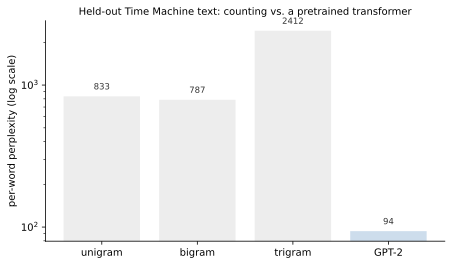

In [9]:
names = ['unigram', 'bigram', 'trigram', 'GPT-2']
vals = [ngram_ppl[n] for n in names]
fig, ax = plt.subplots(figsize=(6.4, 3.8))
bars = ax.bar(names, vals, color=[IO, IO, IO, BLUE])
for b, v in zip(bars, vals):
    ax.text(b.get_x() + b.get_width() / 2, v * 1.12, f'{v:.0f}',
            ha='center', fontsize=8.5, color=TX)
ax.set_yscale('log')
ax.set_ylabel('per-word perplexity (log scale)')
ax.set_title('Held-out Time Machine text: counting vs. a pretrained transformer',
             fontsize=10)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout();

## What perplexity can and cannot tell you

Perplexity is the field's standard yardstick — our own training runs in the next notebook will live and die by their validation perplexity — but every one of the caveats below is a mistake that has appeared in print:

* **It is corpus-relative.**  "GPT-2 has perplexity 25" is not a sentence; "perplexity 25 on WikiText-103's test split, with such-and-such preprocessing" is.  Change the domain, the preprocessing, or even the punctuation (we just watched this) and the number moves.
* **It is tokenizer-relative.**  Per-token perplexity cannot be compared across different tokenizers.  Normalize by words, characters, or bytes for cross-model comparisons — research papers increasingly report **bits per byte** for exactly this reason.
* **It only applies to honest distributions.**  Our `<unk>` trick quietly turned the hardest predictions into easy ones.  Any evaluation that lets a model redefine the event space (skip "bad" tokens, collapse rare words) is buying perplexity on credit.  A fair comparison requires both models to assign probability to the *same* string.
* **Lower is not better at everything.**  Perplexity measures next-token prediction on some corpus — nothing else.  A model fine-tuned into a helpful assistant typically has *worse* perplexity on raw web text than the base model it came from: post-training deliberately moves probability mass away from "whatever the internet would say next".  Judging an instruct model by web-text perplexity would call that regression; users call it the entire point.
* **It compresses a distribution to one number.**  Two models with equal perplexity can fail in different places — one bad at rare words, one bad at long-range coherence.  The number is a summary, not a diagnosis.

For calibration, the trajectory of the field in per-token numbers on standard English benchmarks: n-grams sat in the hundreds; the best pre-transformer neural models (mid-2010s LSTMs) reached roughly 60–80; the full 1.5B GPT-2 hit ~18 on WikiText-103 zero-shot; and models since have pushed well into the single digits.  Each of those drops of "a few bits per token" is a doubling-or-more of predictive sharpness — and, as notebook 1's scaling laws promised, they were bought with predictable quantities of data, parameters, and compute.

In the next notebook we finally change roles: instead of *measuring* someone else's language model, we will train our own decoder-only transformer from scratch — and watch its validation perplexity fall, step by step, from $|V|$ toward something respectable.

## Summary

* **Perplexity** is the exponential of the mean per-token cross-entropy: the inverse geometric mean of the probabilities assigned to what actually occurred — an *effective branching factor*, anchored at 1 (oracle) and $|V|$ (uniform guessing).  One bit of loss = a factor of 2 in perplexity; predicting well and compressing well are the same thing.
* As a geometric mean it is dominated by its worst moments: one zero-probability token makes it infinite, which is why every counting-based model needs **smoothing**.
* **$n$-gram models** turn language modeling into counting.  Context helps (bigram $\ll$ unigram), but sparsity bites fast: the trigram *memorizes* — superb train perplexity, worse-than-bigram test perplexity — because $|V|^n$ outruns any corpus, and counts cannot share strength between related words.
* Measuring a transformer honestly requires a **sliding window** (accumulate total NLL, then divide), and comparing across models requires **tokenizer-independent units** (per-word or per-byte) on the identical string.  Done fairly, GPT-2 beats the best n-gram by an enormous margin — that is pretraining, in one number.
* Perplexity is relative to a corpus, a tokenizer, and a preprocessing pipeline; it measures predictability, not quality, and post-trained assistants are *expected* to have worse web-text perplexity than their base models.

## Exercises

1. **The two ends of the scale.**  Show from the definition that a model assigning uniform probability $1/|V|$ to every token has perplexity exactly $|V|$.  Can a model's perplexity *exceed* $|V|$?  Construct a concrete (mis)behavior that achieves it, and explain why "worse than uniform" requires being confidently wrong rather than merely ignorant.

2. **The smoothing dial.**  Sweep $k$ over $\{10^{-4}, 10^{-3}, \dots, 10\}$ for the bigram model and plot test perplexity against $k$ on log axes.  Explain both ends of the curve you get: what goes wrong as $k \to 0$, and what does the model converge to as $k \to \infty$?

3. **Diagnosing the trigram.**  Compute the fraction of test-set trigrams that never appear in training (and the same for bigrams).  Relate the two coverage numbers to the train/test perplexity table — can you predict, before running it, roughly where a 4-gram model would land?

4. **What does GPT-2 find "likely"?**  Use `quick_ppl` to rank: a grammatical sentence; the same sentence with a subject–verb agreement error; Chomsky's "Colorless green ideas sleep furiously"; and a sensible sentence with one word replaced by a rare synonym.  Does perplexity track *grammaticality* or *plausibility*?  What does that distinction tell you about what next-token training teaches?

5. **The price of context.**  Re-run `ppl(lm, raw_test, stride=s)` for stride $s \in \{1024, 512, 256\}$ (note stride 1024 means *no* context overlap).  Explain the direction of the change: which tokens get better predictions as the stride shrinks, and what does this say about how much GPT-2 actually uses long context?

6. **GPT-2 vs. gzip.**  From GPT-2's total NLL on the raw test text, compute its compression rate in bits per *character*, and compare with `gzip` at maximum compression (`len(gzip.compress(raw_test.encode(), 9))`).  Who wins, by how much, and what would you expect for a modern 100× larger model?

7. **Your own writing.**  Measure GPT-2's perplexity on a page of your own prose, a Wikipedia article, and a source file from one of your projects.  Which does the model find most predictable, and what — precisely — is that a measurement of?